In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

PROCESSED_PATH = '../data/processed/'
OUTPUT_PATH    = '../outputs/'

df_acn = pd.read_csv(PROCESSED_PATH + 'acn_caltech_processed.csv', parse_dates=['connectionTime'])
df_ev  = pd.read_csv(PROCESSED_PATH + 'st_evcdp_processed.csv',    parse_dates=['timestamp'])

print("ACN shape:", df_acn.shape)
print("EV shape :", df_ev.shape)

ACN shape: (14848, 28)
EV shape : (2134080, 15)


In [ ]:
df_acn_ml = df_acn[['kWhDelivered', 'hour_of_day', 'day_of_week', 
                     'is_weekend', 'month', 'stationID', 
                     'session_duration_hrs', 'charging_rate_kw']].dropna()


le = LabelEncoder()
df_acn_ml = df_acn_ml.copy()
df_acn_ml['station_encoded'] = le.fit_transform(df_acn_ml['stationID'].astype(str))

feature_cols_acn = ['hour_of_day', 'day_of_week', 'is_weekend', 
                    'month', 'station_encoded', 'session_duration_hrs']

X_acn = df_acn_ml[feature_cols_acn]
y_acn = df_acn_ml['kWhDelivered']

X_train_acn, X_test_acn, y_train_acn, y_test_acn = train_test_split(
    X_acn, y_acn, test_size=0.2, random_state=42
)

print(f"ACN Train: {X_train_acn.shape}, Test: {X_test_acn.shape}")

ACN Train: (11878, 6), Test: (2970, 6)


In [ ]:
df_ev_ml = df_ev.sample(500000, random_state=42).copy()


df_ev_ml = df_ev_ml.sort_values(['station_id', 'timestamp'])
df_ev_ml['util_lag_1']  = df_ev_ml.groupby('station_id')['utilization_rate'].shift(1)
df_ev_ml['util_lag_12'] = df_ev_ml.groupby('station_id')['utilization_rate'].shift(12)
df_ev_ml['util_lag_24'] = df_ev_ml.groupby('station_id')['utilization_rate'].shift(24)


le_ev = LabelEncoder()
df_ev_ml['station_encoded'] = le_ev.fit_transform(df_ev_ml['station_id'].astype(str))

df_ev_ml.dropna(inplace=True)

feature_cols_ev = ['hour_of_day', 'day_of_week', 'is_weekend', 'month',
                   'station_encoded', 'util_lag_1', 'util_lag_12', 'util_lag_24',
                   'volume', 'duration_mins']

X_ev = df_ev_ml[feature_cols_ev]
y_ev = df_ev_ml['utilization_rate']

X_train_ev, X_test_ev, y_train_ev, y_test_ev = train_test_split(
    X_ev, y_ev, test_size=0.2, random_state=42
)

print(f"EV Train: {X_train_ev.shape}, Test: {X_test_ev.shape}")

EV Train: (395257, 10), Test: (98815, 10)


In [ ]:
print("Training models on ACN data")

models_acn = {
    'Random Forest'  : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'        : xgb.XGBRegressor(n_estimators=100, random_state=42, 
                                         verbosity=0, n_jobs=-1),
    'Gradient Boost' : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results_acn = {}
for name, model in models_acn.items():
    model.fit(X_train_acn, y_train_acn)
    preds = model.predict(X_test_acn)
    results_acn[name] = {
        'RMSE' : round(np.sqrt(mean_squared_error(y_test_acn, preds)), 4),
        'MAE'  : round(mean_absolute_error(y_test_acn, preds), 4),
        'R2'   : round(r2_score(y_test_acn, preds), 4),
        'preds': preds
    }
    print(f"{name}: RMSE={results_acn[name]['RMSE']}, MAE={results_acn[name]['MAE']}, R²={results_acn[name]['R2']}")

Training models on ACN data...
Random Forest: RMSE=5.9695, MAE=3.9207, R²=0.2863
XGBoost: RMSE=6.05, MAE=4.0314, R²=0.2669
Gradient Boost: RMSE=6.0239, MAE=4.0708, R²=0.2732


In [ ]:
print("Training models on ST-EVCDP data")

models_ev = {
    'Random Forest'  : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'        : xgb.XGBRegressor(n_estimators=100, random_state=42, 
                                         verbosity=0, n_jobs=-1),
    'Gradient Boost' : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results_ev = {}
for name, model in models_ev.items():
    model.fit(X_train_ev, y_train_ev)
    preds = model.predict(X_test_ev)
    results_ev[name] = {
        'RMSE' : round(np.sqrt(mean_squared_error(y_test_ev, preds)), 4),
        'MAE'  : round(mean_absolute_error(y_test_ev, preds), 4),
        'R2'   : round(r2_score(y_test_ev, preds), 4),
        'preds': preds
    }
    print(f"{name}: RMSE={results_ev[name]['RMSE']}, MAE={results_ev[name]['MAE']}, R²={results_ev[name]['R2']}")

Training models on ST-EVCDP data...
Random Forest: RMSE=0.0353, MAE=0.0076, R²=0.9892
XGBoost: RMSE=0.0396, MAE=0.0125, R²=0.9864
Gradient Boost: RMSE=0.0512, MAE=0.0156, R²=0.9772


Best ACN model : Random Forest (R²=0.2863)
Best EV model  : Random Forest  (R²=0.9892)


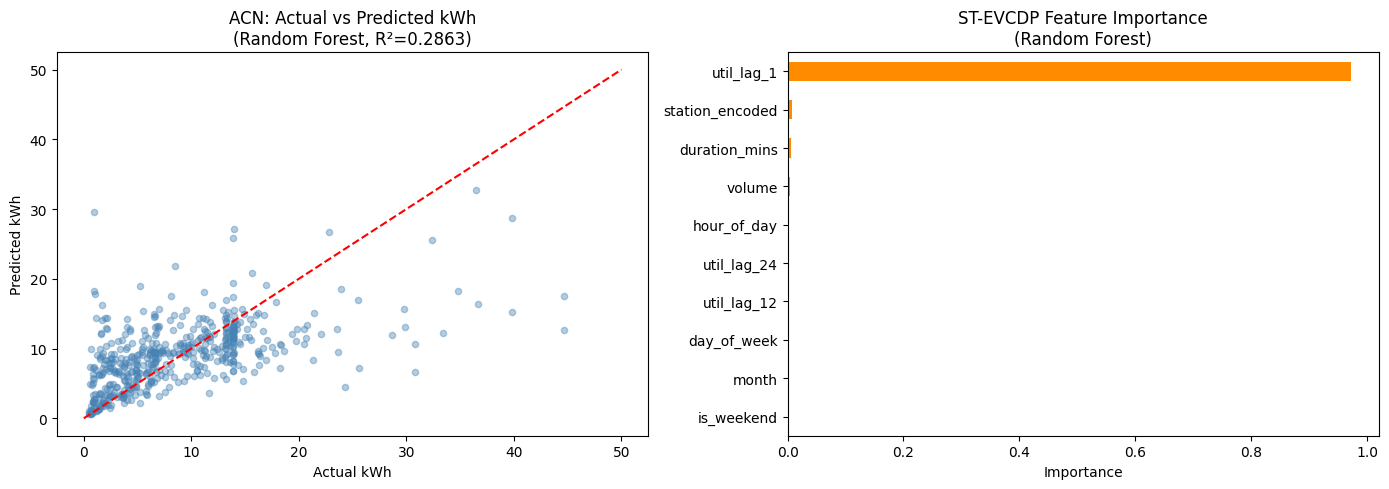

In [ ]:
best_acn_name = max(results_acn, key=lambda x: results_acn[x]['R2'])
best_ev_name  = max(results_ev,  key=lambda x: results_ev[x]['R2'])
best_acn_model = models_acn[best_acn_name]
best_ev_model  = models_ev[best_ev_name]

print(f"Best ACN model : {best_acn_name} (R²={results_acn[best_acn_name]['R2']})")
print(f"Best EV model  : {best_ev_name}  (R²={results_ev[best_ev_name]['R2']})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_test_acn[:500], results_acn[best_acn_name]['preds'][:500], 
                alpha=0.4, color='steelblue', s=20)
axes[0].plot([0, 50], [0, 50], 'r--')
axes[0].set_title(f'ACN: Actual vs Predicted kWh\n({best_acn_name}, R²={results_acn[best_acn_name]["R2"]})')
axes[0].set_xlabel('Actual kWh')
axes[0].set_ylabel('Predicted kWh')


feat_imp = pd.Series(best_ev_model.feature_importances_, index=feature_cols_ev).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title(f'ST-EVCDP Feature Importance\n({best_ev_name})')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'demand_prediction_results.png', bbox_inches='tight')
plt.show()

In [8]:
metrics_rows = []
for name, res in results_acn.items():
    metrics_rows.append({'dataset':'ACN', 'model':name, 
                         'RMSE':res['RMSE'], 'MAE':res['MAE'], 'R2':res['R2']})
for name, res in results_ev.items():
    metrics_rows.append({'dataset':'ST-EVCDP', 'model':name, 
                         'RMSE':res['RMSE'], 'MAE':res['MAE'], 'R2':res['R2']})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(OUTPUT_PATH + 'demand_prediction_metrics.csv', index=False)


ev_test_results = X_test_ev.copy()
ev_test_results['actual_utilization']    = y_test_ev.values
ev_test_results['predicted_utilization'] = results_ev[best_ev_name]['preds']
ev_test_results.to_csv(OUTPUT_PATH + 'ev_demand_predictions.csv', index=False)

print("Saved: demand_prediction_metrics.csv")
print("Saved: ev_demand_predictions.csv")
print("\nFull metrics table:")
print(metrics_df.to_string(index=False))

Saved: demand_prediction_metrics.csv
Saved: ev_demand_predictions.csv

Full metrics table:
 dataset          model   RMSE    MAE     R2
     ACN  Random Forest 5.9695 3.9207 0.2863
     ACN        XGBoost 6.0500 4.0314 0.2669
     ACN Gradient Boost 6.0239 4.0708 0.2732
ST-EVCDP  Random Forest 0.0353 0.0076 0.9892
ST-EVCDP        XGBoost 0.0396 0.0125 0.9864
ST-EVCDP Gradient Boost 0.0512 0.0156 0.9772
